# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [29]:

x = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           3.02e-75
Time:                        14:59:43   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='FocusScore', ylabel='ProductivityScore'>

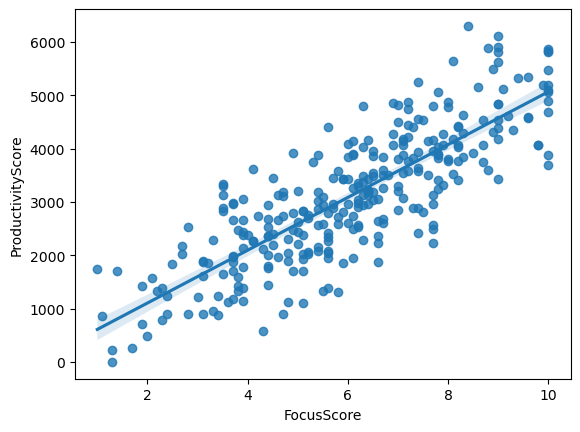

In [30]:
sns.regplot(x = 'FocusScore', y = 'ProductivityScore', data=df)

In [31]:
x = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Sun, 01 Mar 2026   Prob (F-statistic):              0.379
Time:                        15:00:26   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='HoursWorked', ylabel='ProductivityScore'>

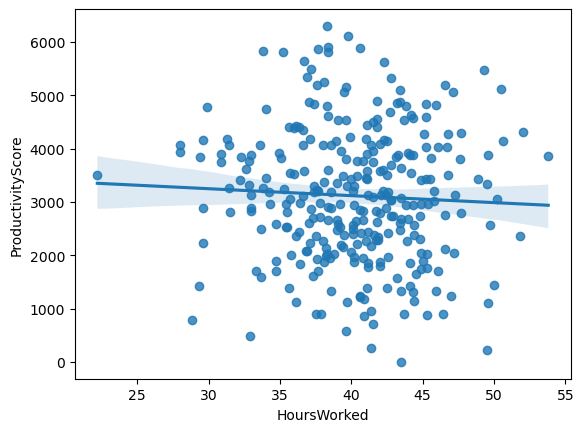

In [32]:
sns.regplot(x = 'HoursWorked', y = 'ProductivityScore', data=df)

In [33]:
x = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Sun, 01 Mar 2026   Prob (F-statistic):              0.726
Time:                        15:01:10   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='YearsAtCompany', ylabel='ProductivityScore'>

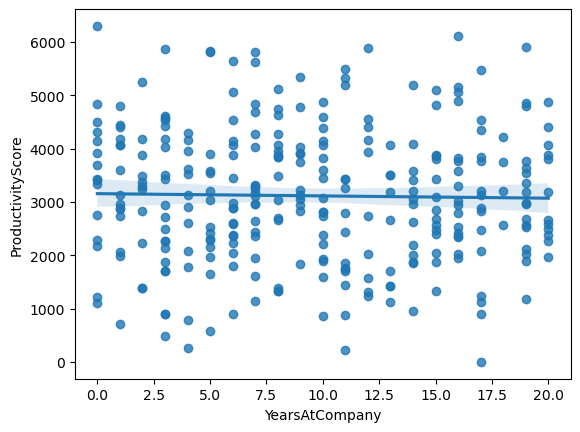

In [34]:
sns.regplot(x = 'YearsAtCompany', y = 'ProductivityScore', data=df)

In [18]:
x = sm.add_constant(df[['FocusScore', 'HoursWorked']])
y = df['ProductivityScore']

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           8.69e-74
Time:                        14:55:35   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         258.8336    366.985      0.705      0.481    -463.386     981.053
FocusScore    494.5564     19.820     24.953      0.000     455.551     533.561
HoursWorked    -3.5345      8.426     -0.419      0.675     -20.117      13.048
==============================================================================
Omnibus:                        0.803   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.669   Jarque-Bera (JB):                0.907
Skew:                           0.072   Prob(JB):                        0.635
Kurtosis:                       2.773   Cond. No.                         366.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
x = sm.add_constant(df[['FocusScore', 'YearsAtCompany']])
y = df['ProductivityScore']

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           8.89e-74
Time:                        14:57:54   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             88.7215    145.130      0.611      0.541    -196.891     374.334
FocusScore       495.2145     19.816     24.990      0.000     456.217     534.212
YearsAtCompany     2.5120      6.904      0.364      0.716     -11.075      16.099
==============================================================================
Omnibus:                        0.768   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.681   Jarque-Bera (JB):                0.883
Skew:                           0.082   Prob(JB):                        0.643
Kurtosis:                       2.791   Cond. No.                         44.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


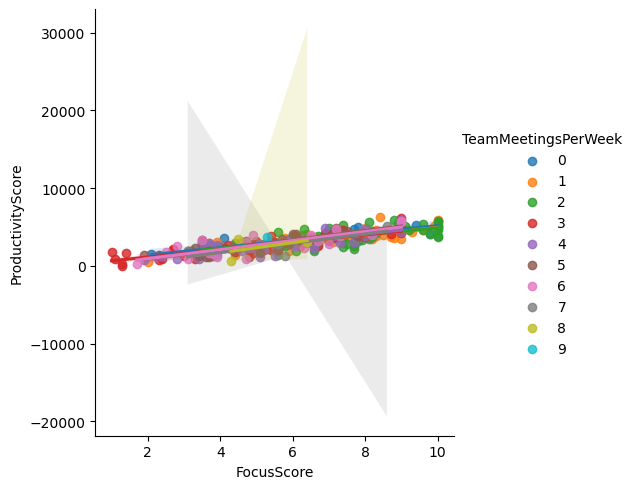

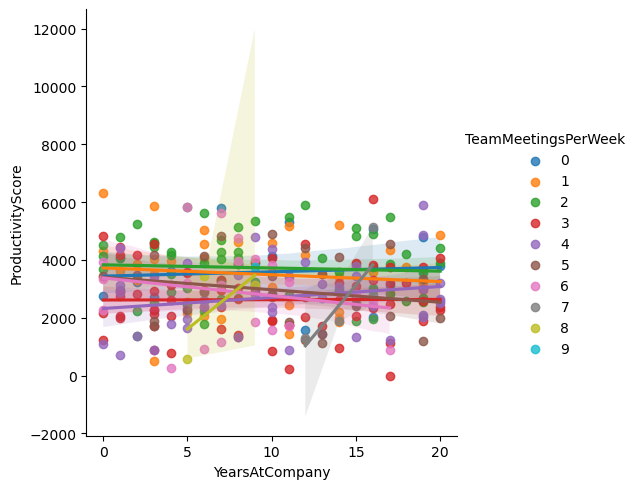

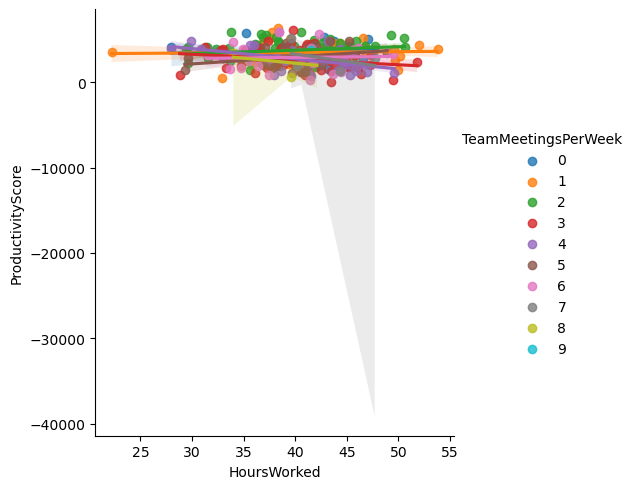

In [43]:
sns.lmplot(x= 'FocusScore', y = 'ProductivityScore', hue = 'TeamMeetingsPerWeek', data=df)
sns.lmplot(x= 'YearsAtCompany', y = 'ProductivityScore', hue = 'TeamMeetingsPerWeek', data=df)
sns.lmplot(x= 'HoursWorked', y = 'ProductivityScore', hue = 'TeamMeetingsPerWeek', data=df)
plt.show()

C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


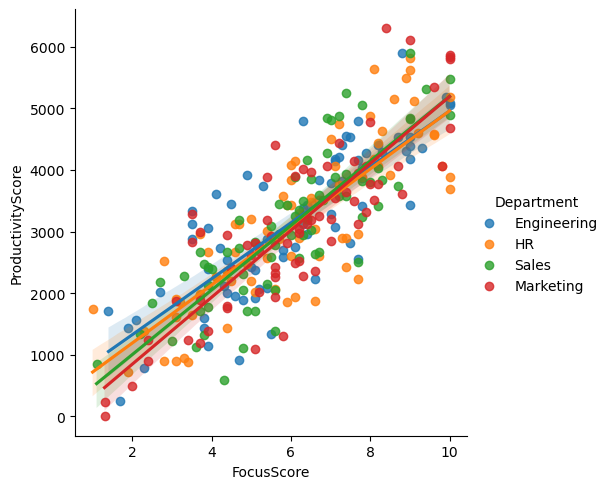

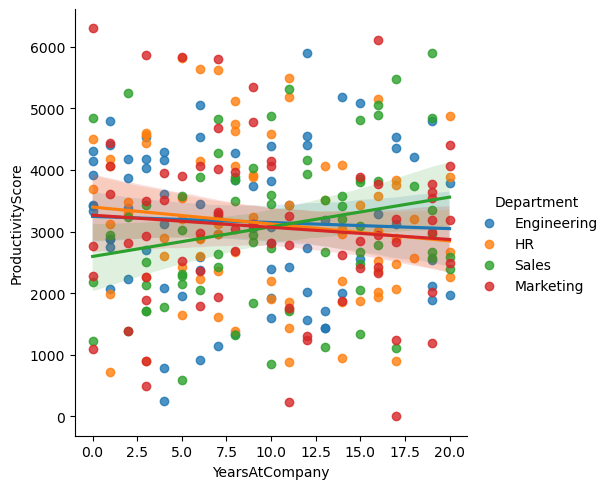

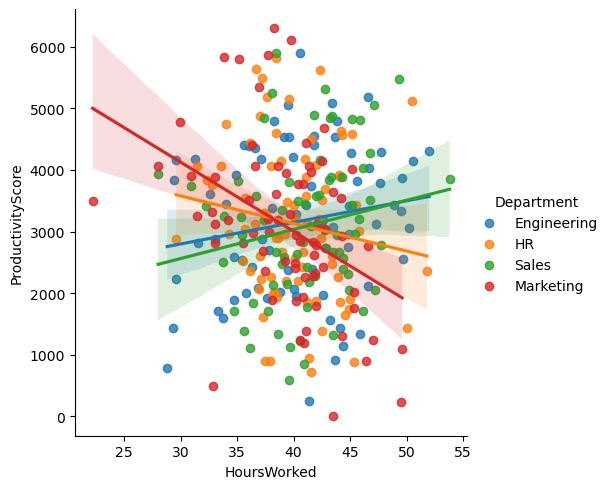

In [45]:
sns.lmplot(x= 'FocusScore', y = 'ProductivityScore', hue = 'Department', data=df)
sns.lmplot(x= 'YearsAtCompany', y = 'ProductivityScore', hue = 'Department', data=df)
sns.lmplot(x= 'HoursWorked', y = 'ProductivityScore', hue = 'Department', data=df)
plt.show()

C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\arnul\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


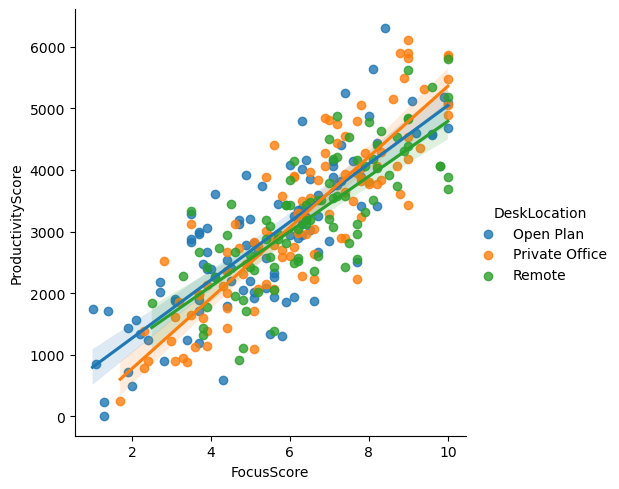

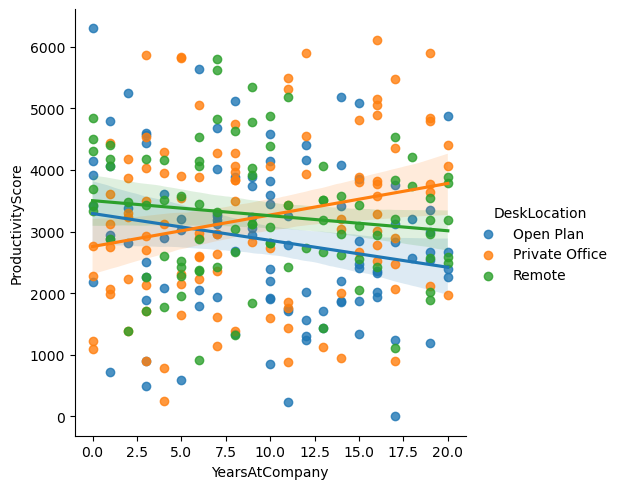

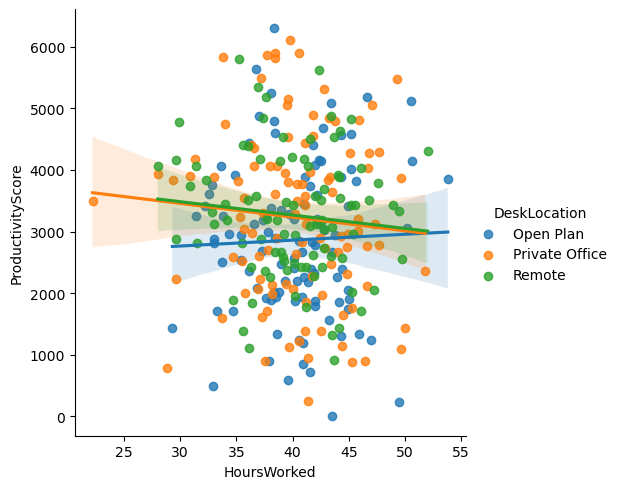

In [44]:
sns.lmplot(x= 'FocusScore', y = 'ProductivityScore', hue = 'DeskLocation', data=df)
sns.lmplot(x= 'YearsAtCompany', y = 'ProductivityScore', hue = 'DeskLocation', data=df)
sns.lmplot(x= 'HoursWorked', y = 'ProductivityScore', hue = 'DeskLocation', data=df)
plt.show()

In [47]:
**Other Factors like Deparment and Location does affect productivity and is important when analyzing
the lowest trend in productivy. In this case it has to deal with the amount of hours employees work and the deparments they're in
I can see a downward trend from the HR and Marketing deparments when it comes to working longer hours and the underpreformance by thier senior employees.
Some recommendations to improve productivity is to monitor the employees working longer hours to avoid possible burnouts that
may impact productivy. Collaborate and find a solution for the underpreforming deparments (Marketing and HR), as well as the senior employees**


SyntaxError: unterminated string literal (detected at line 2) (1386209258.py, line 2)